# Exploratory Data Analysis (EDA)

**Objective:**
Investigate the Online Retail dataset to understand transaction patterns, customer behaviors, product popularity, and data quality issues (missing values, outliers, negative values) that will dictate our data cleaning strategy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Dataset

In [2]:
df = pd.read_excel('../data/raw/Online_Retail.xlsx')
print("Dataset loaded successfully.")
df['Revenue'] = df['Quantity'] * df['UnitPrice']

Dataset loaded successfully.


## 2. General Transaction Behavior

In [3]:
print(f"Total Transactions (Invoices): {df['InvoiceNo'].nunique()}")
print(f"Total Unique Customers: {df['CustomerID'].nunique()}")
print(f"Total Unique Products: {df['StockCode'].nunique()}")


Total Transactions (Invoices): 25900
Total Unique Customers: 4372
Total Unique Products: 4070


## 3. Data Quality & Anomalies
Investigating missing customer IDs, negative quantities (returns), and unusual prices.

In [4]:
missing_customers = df['CustomerID'].isnull().sum()
print(f"Missing Customer IDs: {missing_customers} ({(missing_customers/len(df))*100:.2f}%)")

negative_qty = df[df['Quantity'] < 0].shape[0]
returns = df[df['InvoiceNo'].astype(str).str.startswith('C')].shape[0]
print(f"Rows with negative quantity: {negative_qty}")
print(f"Invoices indicating cancellations (starts with 'C'): {returns}")

zero_prices = df[df['UnitPrice'] == 0].shape[0]
negative_prices = df[df['UnitPrice'] < 0].shape[0]
print(f"Rows with Zero UnitPrice: {zero_prices}")
print(f"Rows with Negative UnitPrice: {negative_prices}")

Missing Customer IDs: 135080 (24.93%)


Rows with negative quantity: 10624
Invoices indicating cancellations (starts with 'C'): 9288
Rows with Zero UnitPrice: 2515
Rows with Negative UnitPrice: 2


## 4. Extreme Values

In [5]:
print("Max Quantity:", df['Quantity'].max())
print("Min Quantity:", df['Quantity'].min())
print("Max Unit Price:", df['UnitPrice'].max())

Max Quantity: 80995
Min Quantity: -80995
Max Unit Price: 38970.0


## 5. Visualizing the Distributions (Excluding Anomalies for Readability)
We filter out the extreme values just to visualize the bulk of the data.

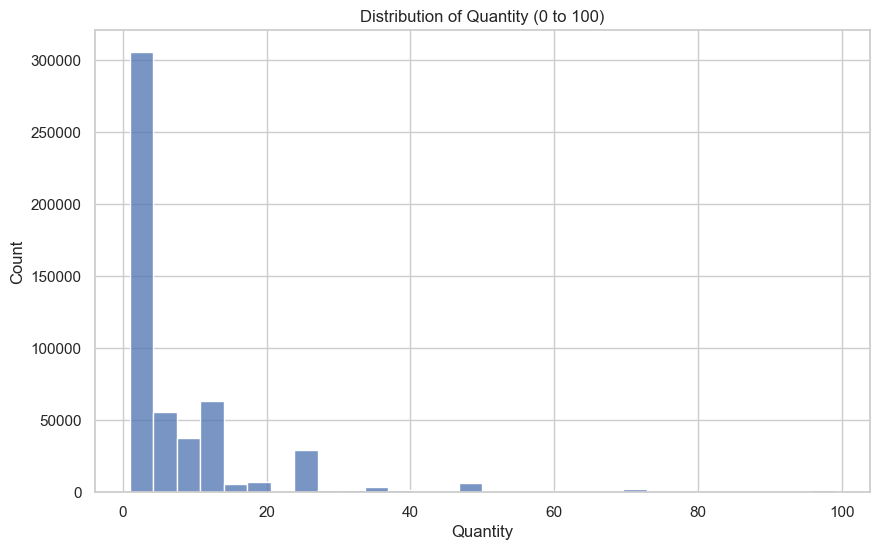

In [6]:
normal_qty = df[(df['Quantity'] > 0) & (df['Quantity'] < 100)]
sns.histplot(normal_qty['Quantity'], bins=30, kde=False)
plt.title('Distribution of Quantity (0 to 100)')
plt.show()

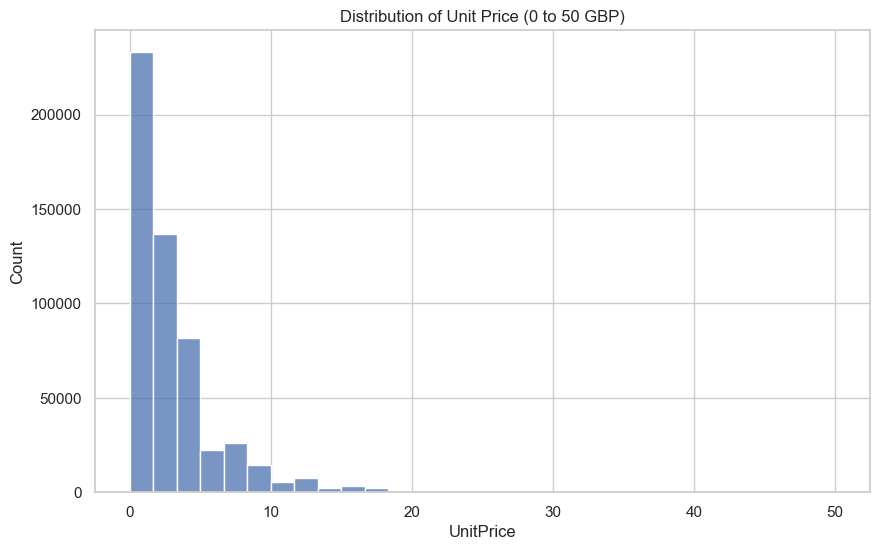

In [7]:
normal_price = df[(df['UnitPrice'] > 0) & (df['UnitPrice'] < 50)]
sns.histplot(normal_price['UnitPrice'], bins=30, kde=False)
plt.title('Distribution of Unit Price (0 to 50 GBP)')
plt.show()

### Key Findings
* **Missing Data**: 135,080 transactions lack a `CustomerID`. Since we are doing customer segmentation, these rows cannot be attributed to any specific entity and must be removed.
* **Returns & Cancellations**: 9,288 invoices start with 'C' and correspond to negative quantities. These indicate returns or cancellations. We must handle these carefully (e.g., removing them if we only care about successful purchases, or keeping them to adjust net revenue).
* **Anomalous Prices**: 2,515 items have a price of 0, and 2 items have a negative price (likely bad data/debt adjustments).
* **Extreme Values**: The quantity ranges wildly from -80,995 to +80,995, and max price is 38,970. This high skewness and presence of extreme outliers will strongly influence distance-based clustering algorithms (like K-Means) and necessitates robust scaling or log-transformation later.